In [3]:
from google.colab import files
uploaded = files.upload()

Saving global_pharmacy_sales_2020_2025_daily_dataset.csv to global_pharmacy_sales_2020_2025_daily_dataset (1).csv


In [4]:
# Install DuckDB
!pip install duckdb -q

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

# Create an in-memory DuckDB connection
con = duckdb.connect()

print("Setup complete.")

Setup complete.


In [5]:
#  RAW DATA LAYER
# ============================================================

con.execute("DROP TABLE IF EXISTS raw_utilization")

con.execute("""
    CREATE TABLE raw_utilization AS
    SELECT *
    FROM 'global_pharmacy_sales_2020_2025_daily_dataset.csv'
""")

raw_count = con.execute("""
    SELECT COUNT(*)
    FROM raw_utilization
""").fetchone()[0]

print(f"Raw rows: {raw_count:,}")

display(
    con.execute("""
        SELECT *
        FROM raw_utilization
        LIMIT 5
    """).df()
)

Raw rows: 177,990


,date,year,month,day,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag
0,2025-10-12,2025,10,12,Middle East,UAE,Chronic,Amlodipine,0-12,328,45.38,4774,466,0
1,2020-09-15,2020,9,15,South Asia,India,Chronic,Amlodipine,26-45,371,75.49,4584,181,1
2,2020-02-26,2020,2,26,Middle East,UAE,Vitamin,Vitamin C,0-12,948,22.51,3934,556,1
3,2025-11-09,2025,11,9,South Asia,Sri Lanka,Chronic,Amlodipine,0-12,275,63.29,4544,330,0
4,2022-04-04,2022,4,4,South America,Argentina,Chronic,Amlodipine,26-45,563,44.28,4284,590,0


In [6]:
# STAGING LAYER
# ============================================================
#
# Staging performs structural cleaning:
#
# - Standardize data types
# - Remove exact duplicate records
# - Keep the original dimensions


con.execute("DROP TABLE IF EXISTS stg_utilization")

con.execute("""
    CREATE TABLE stg_utilization AS

    SELECT DISTINCT

        CAST(date AS DATE) AS date,

        year,
        month,
        day,

        region,
        country,
        category,
        medicine,
        age_group,

        CAST(units_sold AS DOUBLE) AS units_sold,
        CAST(unit_price AS DOUBLE) AS unit_price,
        CAST(stock_level AS DOUBLE) AS stock_level,
        CAST(expiry_days_remaining AS DOUBLE) AS expiry_days_remaining,

        CAST(covid_flag AS INTEGER) AS covid_flag

    FROM raw_utilization
""")

stg_count = con.execute("""
    SELECT COUNT(*)
    FROM stg_utilization
""").fetchone()[0]

duplicates_removed = raw_count - stg_count

print(f"Raw rows: {raw_count:,}")
print(f"Staging rows: {stg_count:,}")
print(f"Exact duplicate rows removed: {duplicates_removed:,}")

Raw rows: 177,990
Staging rows: 175,360
Exact duplicate rows removed: 2,630


In [7]:
# VALIDATE DAILY ANALYTICAL GRAIN
# ============================================================
#
# Expected daily grain: date × country × medicine × age_group
#
# If more than one record exists at this grain, we need to investigate before aggregation.


daily_grain_check = con.execute("""
    SELECT
        date,
        country,
        medicine,
        age_group,
        COUNT(*) AS row_count

    FROM stg_utilization

    GROUP BY
        date,
        country,
        medicine,
        age_group

    HAVING COUNT(*) > 1

    ORDER BY row_count DESC
""").df()

print(f"Daily grain violations: {len(daily_grain_check):,}")

if len(daily_grain_check) > 0:
    display(daily_grain_check.head(20))
else:
    print("PASS: daily observations have the expected grain.")

Daily grain violations: 0
PASS: daily observations have the expected grain.


In [8]:
# CHECK MEDICINE → CATEGORY CONSISTENCY
# ============================================================
# Each medicine should map to one category.


category_check = con.execute("""
    SELECT
        medicine,
        COUNT(DISTINCT category) AS category_count

    FROM stg_utilization

    GROUP BY medicine

    HAVING COUNT(DISTINCT category) > 1
""").df()

if len(category_check) > 0:
    print("WARNING: some medicines map to multiple categories.")
    display(category_check)
else:
    print("PASS: each medicine maps to one category.")

PASS: each medicine maps to one category.


In [9]:
# CLEAN DATA LAYER
# ============================================================
#
# Remove records that cannot be used analytically:
#
# - Missing utilization
# - Negative utilization
# - Missing stock level


con.execute("DROP TABLE IF EXISTS clean_utilization")

con.execute("""
    CREATE TABLE clean_utilization AS

    SELECT *

    FROM stg_utilization

    WHERE units_sold IS NOT NULL
      AND units_sold >= 0
      AND stock_level IS NOT NULL
""")

clean_count = con.execute("""
    SELECT COUNT(*)
    FROM clean_utilization
""").fetchone()[0]

print(f"Clean rows: {clean_count:,}")

print("\nCleaning summary:")
print(f"  Raw rows:              {raw_count:,}")
print(f"  Exact duplicates:      {duplicates_removed:,}")
print(f"  Staging rows:           {stg_count:,}")
print(f"  Clean rows:             {clean_count:,}")

Clean rows: 175,360

Cleaning summary:
  Raw rows:              177,990
  Exact duplicates:      2,630
  Staging rows:           175,360
  Clean rows:             175,360


In [10]:
# CLEAN-LAYER DATA QUALITY CHECK
# ============================================================

clean_quality = con.execute("""
    SELECT

        COUNT(*) AS total_rows,

        COUNT(*) FILTER (
            WHERE date IS NULL
        ) AS null_date,

        COUNT(*) FILTER (
            WHERE medicine IS NULL
        ) AS null_medicine,

        COUNT(*) FILTER (
            WHERE region IS NULL
        ) AS null_region,

        COUNT(*) FILTER (
            WHERE units_sold IS NULL
        ) AS null_units_sold,

        COUNT(*) FILTER (
            WHERE units_sold < 0
        ) AS negative_units_sold,

        COUNT(*) FILTER (
            WHERE stock_level IS NULL
        ) AS null_stock

    FROM clean_utilization
""").df()

display(clean_quality)

,total_rows,null_date,null_medicine,null_region,null_units_sold,negative_units_sold,null_stock
0,175360,0,0,0,0,0,0


In [11]:
# BUILD MONTHLY ANALYTICAL FACT TABLE
# ============================================================
#
# Forecasting grain: medicine × region × month
#
# Target: utilization = observed units sold aggregated to month
#
# IMPORTANT: This is observed utilization, not necessarily unconstrained latent demand.
#
# launch_proxy_date = first observed date in this dataset.


con.execute("DROP TABLE IF EXISTS fact_drug_region_month")

con.execute("""
    CREATE TABLE fact_drug_region_month AS

    WITH first_observed AS (

        SELECT
            medicine,
            region,
            MIN(date) AS launch_proxy_date

        FROM clean_utilization

        GROUP BY
            medicine,
            region
    ),

    monthly_sales AS (

        SELECT

            medicine AS drug_id,

            region,

            category,

            DATE_TRUNC('month', date) AS month,

            SUM(units_sold) AS utilization,

            AVG(stock_level) AS avg_stock_level,

            MIN(stock_level) AS min_stock_level,

            MAX(stock_level) AS max_stock_level,

            AVG(covid_flag) AS covid_share

        FROM clean_utilization

        GROUP BY

            medicine,
            region,
            category,
            DATE_TRUNC('month', date)
    )

    SELECT

        m.drug_id,
        m.region,
        m.category,
        m.month,

        m.utilization,

        m.avg_stock_level,
        m.min_stock_level,
        m.max_stock_level,

        m.covid_share,

        DATEDIFF(
            'month',
            DATE_TRUNC('month', f.launch_proxy_date),
            m.month
        ) AS months_since_launch,

        f.launch_proxy_date

    FROM monthly_sales m

    LEFT JOIN first_observed f

        ON m.drug_id = f.medicine
        AND m.region = f.region

    ORDER BY
        m.drug_id,
        m.region,
        m.month
""")

fact_count = con.execute("""
    SELECT COUNT(*)
    FROM fact_drug_region_month
""").fetchone()[0]

print(f"Fact table rows: {fact_count:,}")

display(
    con.execute("""
        SELECT *
        FROM fact_drug_region_month
        LIMIT 10
    """).df()
)

Fact table rows: 5,760


,drug_id,region,category,month,utilization,avg_stock_level,min_stock_level,max_stock_level,covid_share,months_since_launch,launch_proxy_date
0,Amlodipine,Africa,Chronic,2020-01-01,21195.0,4304.645161,3945.0,4718.0,1.0,0,2020-01-01
1,Amlodipine,Africa,Chronic,2020-02-01,23661.0,4194.931034,1916.0,4661.0,1.0,1,2020-01-01
2,Amlodipine,Africa,Chronic,2020-03-01,23368.0,4217.612903,3877.0,4598.0,1.0,2,2020-01-01
3,Amlodipine,Africa,Chronic,2020-04-01,21257.0,4321.833333,3855.0,4652.0,1.0,3,2020-01-01
4,Amlodipine,Africa,Chronic,2020-05-01,21270.0,4298.225806,3886.0,4666.0,1.0,4,2020-01-01
5,Amlodipine,Africa,Chronic,2020-06-01,19000.0,4385.933333,2634.0,4736.0,1.0,5,2020-01-01
6,Amlodipine,Africa,Chronic,2020-07-01,14615.0,4546.322581,4137.0,4812.0,1.0,6,2020-01-01
7,Amlodipine,Africa,Chronic,2020-08-01,12207.0,4606.290323,4289.0,4868.0,1.0,7,2020-01-01
8,Amlodipine,Africa,Chronic,2020-09-01,13434.0,4547.533333,2797.0,4976.0,1.0,8,2020-01-01
9,Amlodipine,Africa,Chronic,2020-10-01,15349.0,4499.774194,2716.0,4928.0,1.0,9,2020-01-01


In [12]:
# VALIDATE FINAL DATA-MART GRAIN
# Expected: One row per medicine × region × month


fact_grain_check = con.execute("""
    SELECT
        drug_id,
        region,
        month,
        COUNT(*) AS row_count

    FROM fact_drug_region_month

    GROUP BY
        drug_id,
        region,
        month

    HAVING COUNT(*) > 1
""").df()

print(
    f"Duplicate medicine-region-month combinations: "
    f"{len(fact_grain_check):,}"
)

if len(fact_grain_check) == 0:
    print("PASS: final fact table has the correct analytical grain.")
else:
    display(fact_grain_check.head(20))

Duplicate medicine-region-month combinations: 0
PASS: final fact table has the correct analytical grain.


In [13]:
# CHECK TIME-SERIES COVERAGE

# Understand how many months are available for each medicine-region forecasting series.


series_check = con.execute("""
    SELECT

        drug_id,
        region,

        MIN(month) AS first_month,
        MAX(month) AS last_month,

        COUNT(*) AS months_observed

    FROM fact_drug_region_month

    GROUP BY
        drug_id,
        region

    ORDER BY
        drug_id,
        region
""").df()

display(series_check)

print("\nSeries summary:")
display(
    series_check["months_observed"].describe()
)

,drug_id,region,first_month,last_month,months_observed
0,Amlodipine,Africa,2020-01-01,2025-12-01,72
1,Amlodipine,East Asia,2020-01-01,2025-12-01,72
2,Amlodipine,Europe,2020-01-01,2025-12-01,72
3,Amlodipine,Middle East,2020-01-01,2025-12-01,72
4,Amlodipine,North America,2020-01-01,2025-12-01,72
5,Amlodipine,Oceania,2020-01-01,2025-12-01,72
6,Amlodipine,South America,2020-01-01,2025-12-01,72
7,Amlodipine,South Asia,2020-01-01,2025-12-01,72
8,Amoxicillin,Africa,2020-01-01,2025-12-01,72
9,Amoxicillin,East Asia,2020-01-01,2025-12-01,72



Series summary:


,months_observed
count,80.0
mean,72.0
std,0.0
min,72.0
25%,72.0
50%,72.0
75%,72.0
max,72.0


In [14]:
# DEMAND BY MEDICINE
# ============================================================
#
# This identifies product-level differences in observed demand.
# ============================================================

medicine_demand = con.execute("""
    SELECT

        drug_id,

        SUM(utilization) AS total_units,

        AVG(utilization) AS avg_monthly_units,

        MIN(utilization) AS min_monthly_units,

        MAX(utilization) AS max_monthly_units,

        STDDEV(utilization) AS std_monthly_units

    FROM fact_drug_region_month

    GROUP BY
        drug_id

    ORDER BY
        total_units DESC
""").df()

display(medicine_demand)

# DEMAND BY REGION
# ============================================================

region_demand = con.execute("""
    SELECT

        region,

        SUM(utilization) AS total_units,

        AVG(utilization) AS avg_monthly_units,

        COUNT(DISTINCT drug_id) AS medicines

    FROM fact_drug_region_month

    GROUP BY
        region

    ORDER BY
        total_units DESC
""").df()

display(region_demand)

,drug_id,total_units,avg_monthly_units,min_monthly_units,max_monthly_units,std_monthly_units
0,Azithromycin,7896771.0,13709.671875,6275.0,29735.0,4898.490153
1,Paracetamol,7892260.0,13701.840278,6237.0,36443.0,5130.789004
2,Multivitamin,7869649.0,13662.585069,6155.0,32998.0,4988.829913
3,Ibuprofen,7867488.0,13658.833333,6205.0,33072.0,5036.632680
4,Metformin,7865048.0,13654.597222,6239.0,32157.0,5077.411837
5,Vitamin C,7858526.0,13643.274306,6201.0,32765.0,4995.784774
6,Cough Syrup,7847488.0,13624.111111,6044.0,30813.0,5040.724900
7,Cetirizine,7831986.0,13597.197917,6101.0,29500.0,4820.907120
8,Amlodipine,7822352.0,13580.472222,5977.0,32919.0,4930.951092
9,Amoxicillin,7783016.0,13512.180556,6225.0,34008.0,4916.843387


,region,total_units,avg_monthly_units,medicines
0,Middle East,9849229.0,13679.484722,10
1,Oceania,9847959.0,13677.720833,10
2,South Asia,9844922.0,13673.502778,10
3,South America,9838549.0,13664.651389,10
4,East Asia,9837720.0,13663.500000,10
5,North America,9799919.0,13610.998611,10
6,Europe,9782351.0,13586.598611,10
7,Africa,9733935.0,13519.354167,10


,month,total_units
0,2020-01-01,1765362.0
1,2020-02-01,1784111.0
2,2020-03-01,1973751.0
3,2020-04-01,1924169.0
4,2020-05-01,1766832.0
5,2020-06-01,1424825.0
6,2020-07-01,1233943.0
7,2020-08-01,1033542.0
8,2020-09-01,940856.0
9,2020-10-01,1017187.0


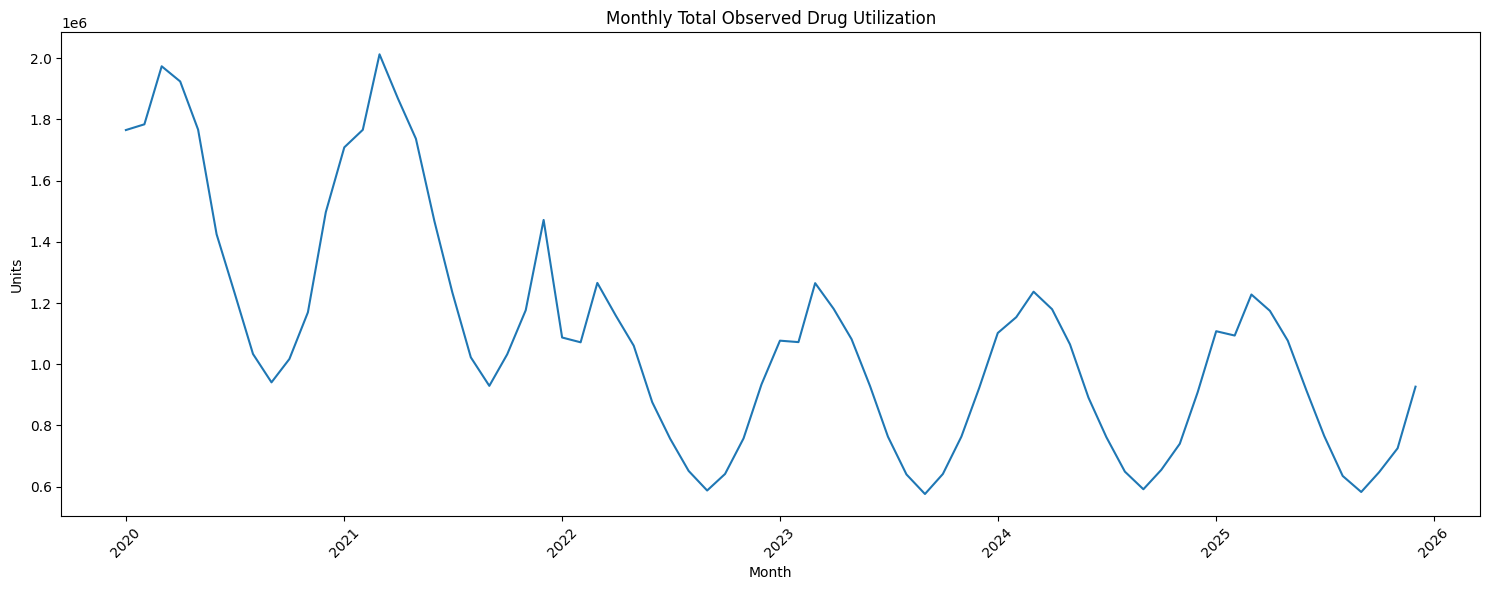

In [15]:
# ============================================================
# 13. MONTHLY TOTAL OBSERVED DEMAND
# ============================================================
#
# This provides a high-level time-series view after the SQL
# transformation into monthly data.
# ============================================================

monthly_demand = con.execute("""
    SELECT

        month,

        SUM(utilization) AS total_units

    FROM fact_drug_region_month

    GROUP BY
        month

    ORDER BY
        month
""").df()

display(monthly_demand.head(20))
# ============================================================
# 14. VISUAL VALIDATION OF MONTHLY AGGREGATION
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_demand["month"],
    monthly_demand["total_units"]
)

plt.title("Monthly Total Observed Drug Utilization")
plt.xlabel("Month")
plt.ylabel("Units")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
# WINDOW FUNCTION — PREVIOUS MONTH DEMAND
# ============================================================
#
# LAG() allows us to compare each month's utilization with the
# previous month within the same medicine-region series.

mom_demand = con.execute("""
    SELECT

        drug_id,
        region,
        month,
        utilization,

        LAG(utilization, 1) OVER (

            PARTITION BY
                drug_id,
                region

            ORDER BY
                month

        ) AS previous_month_demand

    FROM fact_drug_region_month

    ORDER BY
        drug_id,
        region,
        month
""").df()

display(mom_demand.head(20))

# MONTH-OVER-MONTH GROWTH
#  MoM growth is calculated only when a valid previous month
# exists and previous demand is greater than zero.
# ============================================================

mom_growth = con.execute("""
    WITH lagged AS (

        SELECT

            drug_id,
            region,
            month,
            utilization,

            LAG(utilization, 1) OVER (

                PARTITION BY
                    drug_id,
                    region

                ORDER BY
                    month

            ) AS previous_month_demand

        FROM fact_drug_region_month
    )

    SELECT

        drug_id,
        region,
        month,
        utilization,
        previous_month_demand,

        CASE

            WHEN previous_month_demand IS NULL
                THEN NULL

            WHEN previous_month_demand = 0
                THEN NULL

            ELSE

                100.0 *
                (
                    utilization - previous_month_demand
                )
                / previous_month_demand

        END AS mom_growth_pct

    FROM lagged

    ORDER BY
        drug_id,
        region,
        month
""").df()

display(mom_growth.head(20))

,drug_id,region,month,utilization,previous_month_demand
0,Amlodipine,Africa,2020-01-01,21195.0,NaN
1,Amlodipine,Africa,2020-02-01,23661.0,21195.0
2,Amlodipine,Africa,2020-03-01,23368.0,23661.0
3,Amlodipine,Africa,2020-04-01,21257.0,23368.0
4,Amlodipine,Africa,2020-05-01,21270.0,21257.0
5,Amlodipine,Africa,2020-06-01,19000.0,21270.0
6,Amlodipine,Africa,2020-07-01,14615.0,19000.0
7,Amlodipine,Africa,2020-08-01,12207.0,14615.0
8,Amlodipine,Africa,2020-09-01,13434.0,12207.0
9,Amlodipine,Africa,2020-10-01,15349.0,13434.0


,drug_id,region,month,utilization,previous_month_demand,mom_growth_pct
0,Amlodipine,Africa,2020-01-01,21195.0,NaN,NaN
1,Amlodipine,Africa,2020-02-01,23661.0,21195.0,11.634820
2,Amlodipine,Africa,2020-03-01,23368.0,23661.0,-1.238325
3,Amlodipine,Africa,2020-04-01,21257.0,23368.0,-9.033721
4,Amlodipine,Africa,2020-05-01,21270.0,21257.0,0.061156
5,Amlodipine,Africa,2020-06-01,19000.0,21270.0,-10.672308
6,Amlodipine,Africa,2020-07-01,14615.0,19000.0,-23.078947
7,Amlodipine,Africa,2020-08-01,12207.0,14615.0,-16.476223
8,Amlodipine,Africa,2020-09-01,13434.0,12207.0,10.051610
9,Amlodipine,Africa,2020-10-01,15349.0,13434.0,14.254876


In [17]:
# ============================================================
# 17. SQL WINDOW FUNCTION — ROLLING 3-MONTH DEMAND
# ============================================================
#
# Rolling averages smooth short-term variation.
#
# This is another example of a SQL transformation that can
# support downstream forecasting.
# ============================================================

rolling_demand = con.execute("""
    SELECT

        drug_id,
        region,
        month,
        utilization,

        AVG(utilization) OVER (

            PARTITION BY
                drug_id,
                region

            ORDER BY
                month

            ROWS BETWEEN
                2 PRECEDING
                AND CURRENT ROW

        ) AS rolling_3m_demand

    FROM fact_drug_region_month

    ORDER BY
        drug_id,
        region,
        month
""").df()

display(rolling_demand.head(20))

,drug_id,region,month,utilization,rolling_3m_demand
0,Amlodipine,Africa,2020-01-01,21195.0,21195.000000
1,Amlodipine,Africa,2020-02-01,23661.0,22428.000000
2,Amlodipine,Africa,2020-03-01,23368.0,22741.333333
3,Amlodipine,Africa,2020-04-01,21257.0,22762.000000
4,Amlodipine,Africa,2020-05-01,21270.0,21965.000000
5,Amlodipine,Africa,2020-06-01,19000.0,20509.000000
6,Amlodipine,Africa,2020-07-01,14615.0,18295.000000
7,Amlodipine,Africa,2020-08-01,12207.0,15274.000000
8,Amlodipine,Africa,2020-09-01,13434.0,13418.666667
9,Amlodipine,Africa,2020-10-01,15349.0,13663.333333


In [18]:
# CHECK FOR MISSING MONTHS
# ============================================================
#
# A continuous monthly index is important for time-series forecasting.
#
# We compare: expected number of months vs actual number of rows


missing_month_check = con.execute("""
    WITH series_dates AS (

        SELECT

            drug_id,
            region,

            MIN(month) AS first_month,
            MAX(month) AS last_month

        FROM fact_drug_region_month

        GROUP BY
            drug_id,
            region
    ),

    expected AS (

        SELECT

            drug_id,
            region,

            DATE_DIFF(
                'month',
                first_month,
                last_month
            ) + 1 AS expected_months

        FROM series_dates
    ),

    actual AS (

        SELECT

            drug_id,
            region,

            COUNT(*) AS actual_months

        FROM fact_drug_region_month

        GROUP BY
            drug_id,
            region
    )

    SELECT

        e.drug_id,
        e.region,

        e.expected_months,
        a.actual_months,

        e.expected_months - a.actual_months
            AS missing_months

    FROM expected e

    INNER JOIN actual a

        ON e.drug_id = a.drug_id
        AND e.region = a.region

    ORDER BY
        missing_months DESC
""").df()

display(missing_month_check)

,drug_id,region,expected_months,actual_months,missing_months
0,Amlodipine,Middle East,72,72,0
1,Amlodipine,North America,72,72,0
2,Amlodipine,South Asia,72,72,0
3,Amoxicillin,Middle East,72,72,0
4,Amoxicillin,North America,72,72,0
5,Amoxicillin,South Asia,72,72,0
6,Azithromycin,Middle East,72,72,0
7,Azithromycin,North America,72,72,0
8,Azithromycin,South Asia,72,72,0
9,Cetirizine,Africa,72,72,0


In [19]:
# FINAL DATA-QUALITY ASSERTIONS


print("=" * 70)
print("FINAL DATA-QUALITY ASSERTIONS")
print("=" * 70)


# ------------------------------------------------------------
# Assertion 1 — No duplicate medicine-region-month
# ------------------------------------------------------------

assert len(fact_grain_check) == 0, (
    f"FAILED: {len(fact_grain_check)} "
    "duplicate medicine-region-month combinations found."
)

print("PASS: no duplicate medicine-region-month rows")


# ------------------------------------------------------------
# Assertion 2 — No negative utilization
# ------------------------------------------------------------

negative_utilization = con.execute("""
    SELECT COUNT(*)
    FROM fact_drug_region_month
    WHERE utilization < 0
""").fetchone()[0]

assert negative_utilization == 0, (
    f"FAILED: {negative_utilization} negative utilization rows found."
)

print("PASS: no negative utilization values")


# ------------------------------------------------------------
# Assertion 3 — No NULL utilization
# ------------------------------------------------------------

null_utilization = con.execute("""
    SELECT COUNT(*)
    FROM fact_drug_region_month
    WHERE utilization IS NULL
""").fetchone()[0]

assert null_utilization == 0, (
    f"FAILED: {null_utilization} NULL utilization rows found."
)

print("PASS: no NULL utilization values")


# ------------------------------------------------------------
# Assertion 4 — Launch proxy exists
# ------------------------------------------------------------

null_launch_proxy = con.execute("""
    SELECT COUNT(*)
    FROM fact_drug_region_month
    WHERE launch_proxy_date IS NULL
""").fetchone()[0]

assert null_launch_proxy == 0, (
    f"FAILED: {null_launch_proxy} rows have no launch proxy."
)

print("PASS: every series has a launch_proxy_date")


# ------------------------------------------------------------
# Assertion 5 — No negative months_since_launch
# ------------------------------------------------------------

negative_lifecycle = con.execute("""
    SELECT COUNT(*)
    FROM fact_drug_region_month
    WHERE months_since_launch < 0
""").fetchone()[0]

assert negative_lifecycle == 0, (
    f"FAILED: {negative_lifecycle} negative "
    "months_since_launch values found."
)

print("PASS: months_since_launch is non-negative")


# ------------------------------------------------------------
# Assertion 6 — No time-series gaps
# ------------------------------------------------------------

gap_count = len(
    missing_month_check[
        missing_month_check["missing_months"] != 0
    ]
)

assert gap_count == 0, (
    f"FAILED: {gap_count} medicine-region series contain gaps."
)

print("PASS: no gaps in observed monthly index")


# ------------------------------------------------------------
# Assertion 7 — Medicine/category consistency
# ------------------------------------------------------------

assert len(category_check) == 0, (
    "FAILED: at least one medicine maps to multiple categories."
)

print("PASS: medicine-category mapping is consistent")


print("\nALL DATA-QUALITY ASSERTIONS PASSED.")

FINAL DATA-QUALITY ASSERTIONS
PASS: no duplicate medicine-region-month rows
PASS: no negative utilization values
PASS: no NULL utilization values
PASS: every series has a launch_proxy_date
PASS: months_since_launch is non-negative
PASS: no gaps in observed monthly index
PASS: medicine-category mapping is consistent

ALL DATA-QUALITY ASSERTIONS PASSED.


In [20]:
# FINAL DATA-MART SUMMARY
# ============================================================

summary = con.execute("""
    SELECT

        COUNT(*) AS rows,

        COUNT(DISTINCT drug_id) AS medicines,

        COUNT(DISTINCT region) AS regions,

        COUNT(DISTINCT month) AS months,

        MIN(month) AS first_month,

        MAX(month) AS last_month

    FROM fact_drug_region_month
""").df()

display(summary)

,rows,medicines,regions,months,first_month,last_month
0,5760,10,8,72,2020-01-01,2025-12-01


In [21]:
# EXPORT FINAL DATA MART
# ============================================================

fact_df = con.execute("""
    SELECT *

    FROM fact_drug_region_month

    ORDER BY
        drug_id,
        region,
        month
""").df()

fact_df.to_csv(
    "fact_drug_region_month.csv",
    index=False
)

print("Saved: fact_drug_region_month.csv")
print(f"Rows exported: {len(fact_df):,}")

Saved: fact_drug_region_month.csv
Rows exported: 5,760


In [22]:
# EXPORT SQL-DERIVED FEATURES
# ============================================================
#
# These are analytical features created using SQL window functions.


sql_features = con.execute("""
    WITH lagged AS (

        SELECT

            drug_id,
            region,
            category,
            month,
            utilization,

            avg_stock_level,
            min_stock_level,
            max_stock_level,
            covid_share,

            months_since_launch,
            launch_proxy_date,

            LAG(utilization, 1) OVER (
                PARTITION BY drug_id, region
                ORDER BY month
            ) AS previous_month_demand,

            AVG(utilization) OVER (
                PARTITION BY drug_id, region
                ORDER BY month
                ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
            ) AS rolling_3m_demand

        FROM fact_drug_region_month
    )

    SELECT

        *,

        CASE

            WHEN previous_month_demand IS NULL
                THEN NULL

            WHEN previous_month_demand = 0
                THEN NULL

            ELSE

                100.0 *
                (
                    utilization - previous_month_demand
                )
                / previous_month_demand

        END AS mom_growth_pct

    FROM lagged

    ORDER BY
        drug_id,
        region,
        month
""").df()

sql_features.to_csv(
    "fact_drug_region_month_sql_features.csv",
    index=False
)

print(
    "Saved: fact_drug_region_month_sql_features.csv"
)

print(
    f"Rows exported: {len(sql_features):,}"
)

Saved: fact_drug_region_month_sql_features.csv
Rows exported: 5,760
